# Module Imports 

### Note that project root path should be in your OS path so that you can access other modules in your project while in this jupyter notebook

In [61]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

# Loading and Preparing Data

## Phase 1

### I have used pandas here to prepare a table like dataframe to store the data.
df_X is the dataframe for audio samples \
df_X is the dataframe for audio labels

In [62]:
# load & preprocess
P1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
P1_samples = pd.DataFrame(P1_data['x'].T)
P1_labels  = pd.DataFrame(P1_data['y'].T, columns=['y'])
P1_df = pd.concat([P1_samples, P1_labels], axis=1).dropna().sample(frac=1, random_state=42)
shuffled_df = P1_df.sample(frac=1, random_state=42).reset_index(drop=True)
P1_df_X = shuffled_df.iloc[:, :-1]
P1_df_Y = shuffled_df.iloc[:, -1]


### Data can be extracted using Extract_Features
**Use Extract_Features object from ../data_classes/decomposition.py**

**Use "feature" argument in Extract_Features to choose which feature extraction method you want or add your own if you want.**

**By default Extract_Features returns a Pytorch dataset to be used for pytorch train/test/val loops**

In [50]:
## Look into Extract_Features class in ../data_classes/decomposition.py for available feature extraction methods.

## This is how you get raw audio data as a Pytorch dataset
P1_raw = Extract_Features(P1_df_X, P1_df_Y, feature='raw')

In [51]:
## This is how you can extract fetaures in the form of numpy arrays
print(P1_raw.get_samples().shape, P1_raw.get_labels().shape)

(3309, 36000) (3309,)


### Waveform Visualisation

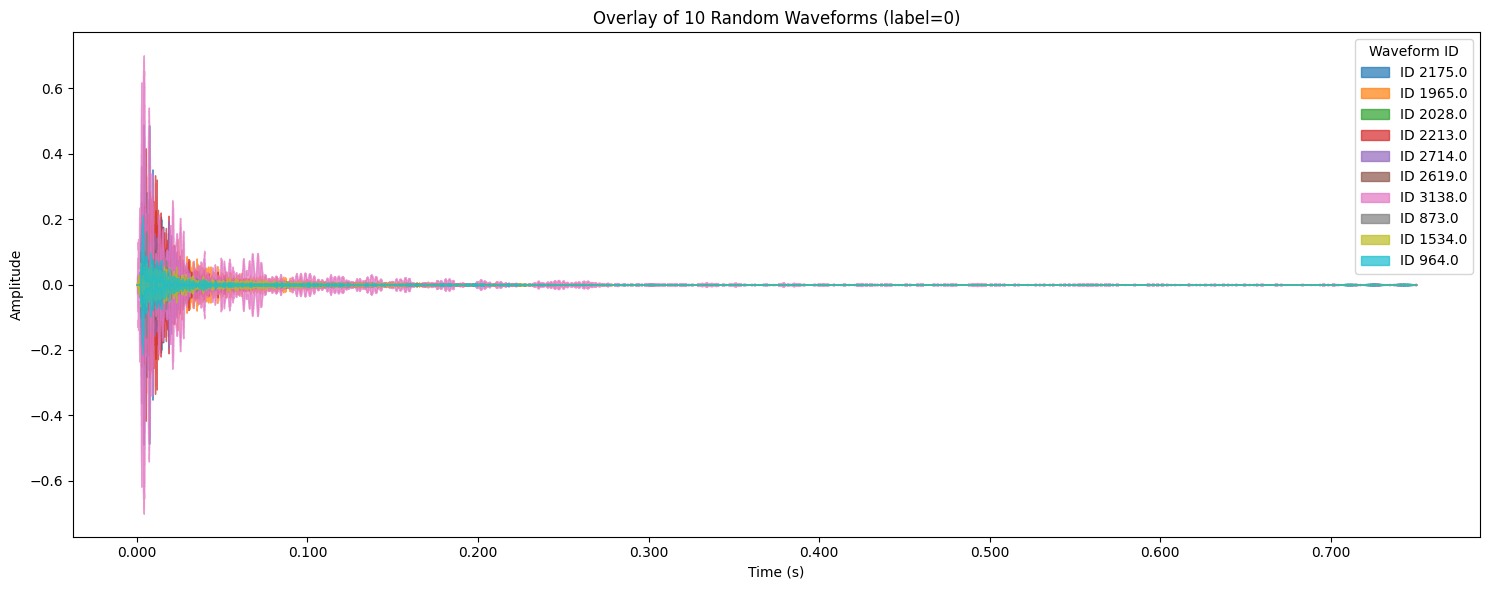

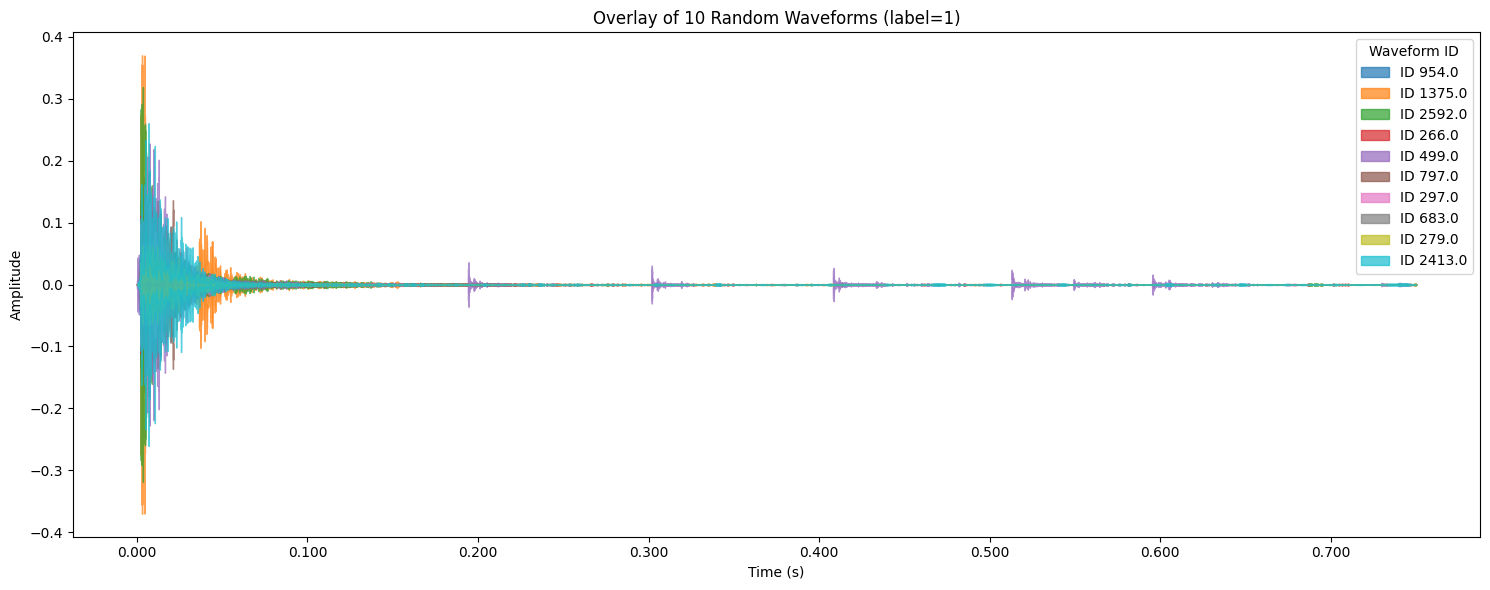

In [63]:
import matplotlib.cm as cm
import numpy as np
import librosa.display

P1_sr = 48000
samples = P1_df[P1_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P1_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

samples = P1_df[P1_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P1_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

### PCA Analysis to compare with previous research paper

**PCA feature in extract features lets you choose either explained_variance or number of components you want.**

Use parameter "explained_variance" or "n_components"

In [53]:
P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=0.95)

In [54]:
print("Number of components explaining 95% variance:", P1_PCA.get_samples().shape[1])
print(P1_PCA.get_samples().shape, P1_PCA.get_labels().shape)


Number of components explaining 95% variance: 396
(3309, 396) (3309,)


**However to compare performance on different combinations of extracted features and type of classification model used we need to create more pca objects**

In [64]:
# === PCA EV sweep with fixed nb_hidden {256,128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import torch
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os


explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [256, 128, 64, 32]        #fixed hidden sizes
batch_size = 32
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

results = []

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    #PCA features via Extract_Features
    P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P1_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds,  test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P1_PCA.get_samples()
    y = P1_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    #SVM baseline (no hidden layers)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))
    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc,
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    #MLP variants over fixed hidden sizes
    for h in hidden_grid:
        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP",         "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P1.pth")

            # Train
            loops.train(
                model=model,
                model_path=model_path,
                train_loader=train_loader,
                val=False,
                val_loader=None,
                batch_size=batch_size,
                lr=1e-3,
                weight_decay=0,
                optim="adam",
                epochs=epochs,
            )

            # Test and get accuracy directly
            acc = loops.test(
                model=model,
                model_path=model_path,
                test_loader=test_loader,
                report=False,   # set True to see confusion matrix / report
                score=True,
                device=device_str
            )

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })

# ---- Results & Plot ----
df_res = pd.DataFrame(results).sort_values(["explained_variance", "model", "nb_hidden"]).reset_index(drop=True)

# Plot: color = model, line-dash = nb_hidden (so you can see how hidden width impacts each model)
fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes: 256, 128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.4f"}
)
fig.update_layout(hovermode="x unified", yaxis_tickformat=".2%", xaxis=dict(dtick=5))
fig.show()

display(df_res)

[INFO] EPOCH: 1/20
Train loss: 0.912505, Train accuracy: 0.6641
[INFO] EPOCH: 2/20
Train loss: 0.688341, Train accuracy: 0.7253
[INFO] EPOCH: 3/20
Train loss: 0.671297, Train accuracy: 0.7435
[INFO] EPOCH: 4/20
Train loss: 0.637084, Train accuracy: 0.7684
[INFO] EPOCH: 5/20
Train loss: 0.592928, Train accuracy: 0.7643
[INFO] EPOCH: 6/20
Train loss: 0.602746, Train accuracy: 0.7911
[INFO] EPOCH: 7/20
Train loss: 0.564990, Train accuracy: 0.8017
[INFO] EPOCH: 8/20
Train loss: 0.555735, Train accuracy: 0.8145
[INFO] EPOCH: 9/20
Train loss: 0.551868, Train accuracy: 0.8289
[INFO] EPOCH: 10/20
Train loss: 0.543652, Train accuracy: 0.8228
[INFO] EPOCH: 11/20
Train loss: 0.538465, Train accuracy: 0.8394
[INFO] EPOCH: 12/20
Train loss: 0.550249, Train accuracy: 0.8349
[INFO] EPOCH: 13/20
Train loss: 0.529623, Train accuracy: 0.8391
[INFO] EPOCH: 14/20
Train loss: 0.530266, Train accuracy: 0.8470
[INFO] EPOCH: 15/20
Train loss: 0.524026, Train accuracy: 0.8504
[INFO] EPOCH: 16/20
Train loss: 0.

,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,0.814199,87,H=[128]
1,80,MLP (1-layer),256,0.805136,87,H=[256]
2,80,MLP (1-layer),32,0.794562,87,H=[32]
3,80,MLP (1-layer),64,0.808157,87,H=[64]
4,80,MLP (2-layer),128,0.856495,87,"H=[128, 64]"
...,...,...,...,...,...,...
99,99,MLP (3-layer),128,0.850453,1186,"H=[128, 64, 32]"
100,99,MLP (3-layer),256,0.832326,1186,"H=[256, 128, 64]"
101,99,MLP (3-layer),32,0.821752,1186,"H=[32, 16, 8]"
102,99,MLP (3-layer),64,0.839879,1186,"H=[64, 32, 16]"


### Best Combination

[RETRAIN] EV=90%, model=MLP (2-layer), nb_hidden=256
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp2_ev90_h256_P1_RETRAIN.pth
[INFO] EPOCH: 1/20
Train loss: 0.608423, Train accuracy: 0.7121
[INFO] EPOCH: 2/20
Train loss: 0.483642, Train accuracy: 0.8304
[INFO] EPOCH: 3/20
Train loss: 0.441747, Train accuracy: 0.8697
[INFO] EPOCH: 4/20
Train loss: 0.370634, Train accuracy: 0.9154
[INFO] EPOCH: 5/20
Train loss: 0.334576, Train accuracy: 0.9380
[INFO] EPOCH: 6/20
Train loss: 0.305719, Train accuracy: 0.9645
[INFO] EPOCH: 7/20
Train loss: 0.290870, Train accuracy: 0.9705
[INFO] EPOCH: 8/20
Train loss: 0.267848, Train accuracy: 0.9830
[INFO] EPOCH: 9/20
Train loss: 0.261431, Train accuracy: 0.9864
[INFO] EPOCH: 10/20
Train loss: 0.247550, Train accuracy: 0.9921
[INFO] EPOCH: 11/20
Train loss: 0.253288, Train accuracy: 0.9906
[INFO] EPOCH: 12/20
Train loss: 0.240318, Train accuracy: 0.9955
[INFO] EPOCH: 13/20
Train loss: 0.230930, Train accuracy: 0.9981
[INFO] EPOCH: 14/20
Train l

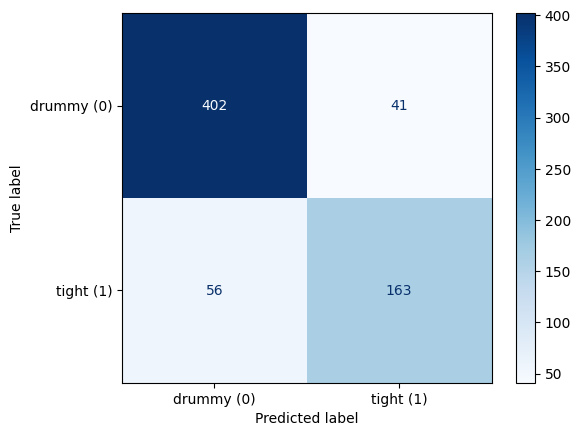


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.88      0.91      0.89       443
   tight (1)       0.80      0.74      0.77       219

    accuracy                           0.85       662
   macro avg       0.84      0.83      0.83       662
weighted avg       0.85      0.85      0.85       662

[RETRAIN] Accuracy (report=True): 0.8535
[GRAPH] Saved to: ../assets/final_report_assets/best_model_mlp2_ev90_h256_P1_RETRAIN.png (and/or .pdf)


In [68]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)

import os, shutil
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 90
BEST_MODEL_NAME = "MLP (2-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 256               # 256 | 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag       = ctor_to_tag[ctor_name]

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)
# fresh path so we don't rely on old checkpoints
model_path = os.path.join(model_dir, f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P1_RETRAIN.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P1_PCA_best = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=best_ev)

# Split (same seed/stratify as before)
y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

# Torch loaders
full_ds   = P1_PCA_best
train_ds  = Subset(full_ds, train_idx.tolist())
test_ds   = Subset(full_ds,  test_idx.tolist())
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P1_PCA_best.get_samples()
input_dim   = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20  # adjust if you want
loops.train(
    model=model,
    model_path=model_path,
    train_loader=train_loader,
    val=False,
    val_loader=None,
    batch_size=batch_size,
    lr=1e-3,
    weight_decay=0,
    optim="adam",
    epochs=epochs,
)

# ----------------- TEST (with report) -----------------
acc = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,   # show confusion matrix + classification report
    score=True,
    device=device_str
)
print(f"[RETRAIN] Accuracy (report=True): {acc:.4f}")

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/final_report_assets/best_model_{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P1_RETRAIN"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename=graph_fname,
)
print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

## Phase 2

### Loading Phase 2 data similar to phase 1

In [69]:
# load & preprocess
P2_data = sio.loadmat('../data/phase2_data_20220215.mat')
P2_samples = pd.DataFrame(P2_data['x'].T)
P2_labels  = pd.DataFrame(P2_data['y'].T, columns=['y'])
P2_df = pd.concat([P2_samples, P2_labels], axis=1).dropna().sample(frac=1, random_state=42)
shuffled_df = P2_df.sample(frac=1, random_state=42).reset_index(drop=True)
P2_df_X = shuffled_df.iloc[:, :-1]
P2_df_Y = shuffled_df.iloc[:, -1]

### Extracting raw features in torch dataset form

In [70]:
P2_raw = Extract_Features(P2_df_X, P2_df_Y, feature='raw')

In [71]:
## This is how you can extract fetaures in the form of numpy arrays
print(P2_raw.get_samples().shape, P2_raw.get_labels().shape)

(8440, 4800) (8440,)


### Waveform Visualisation

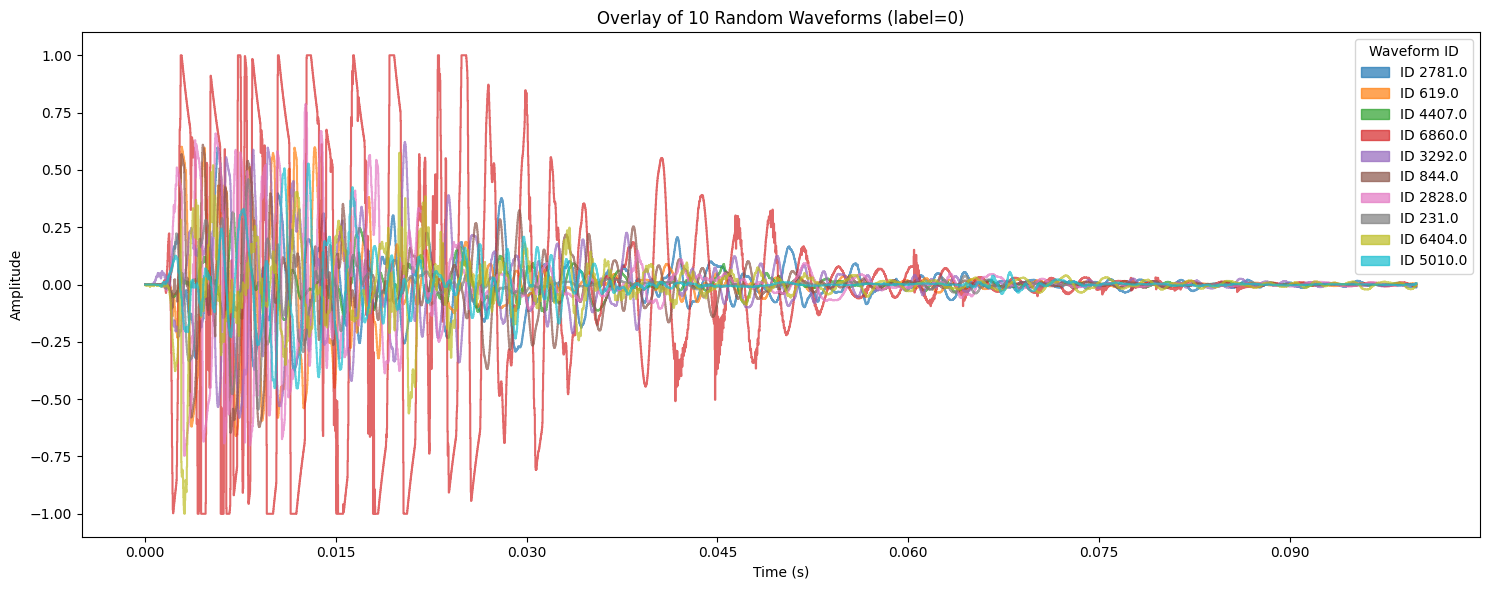

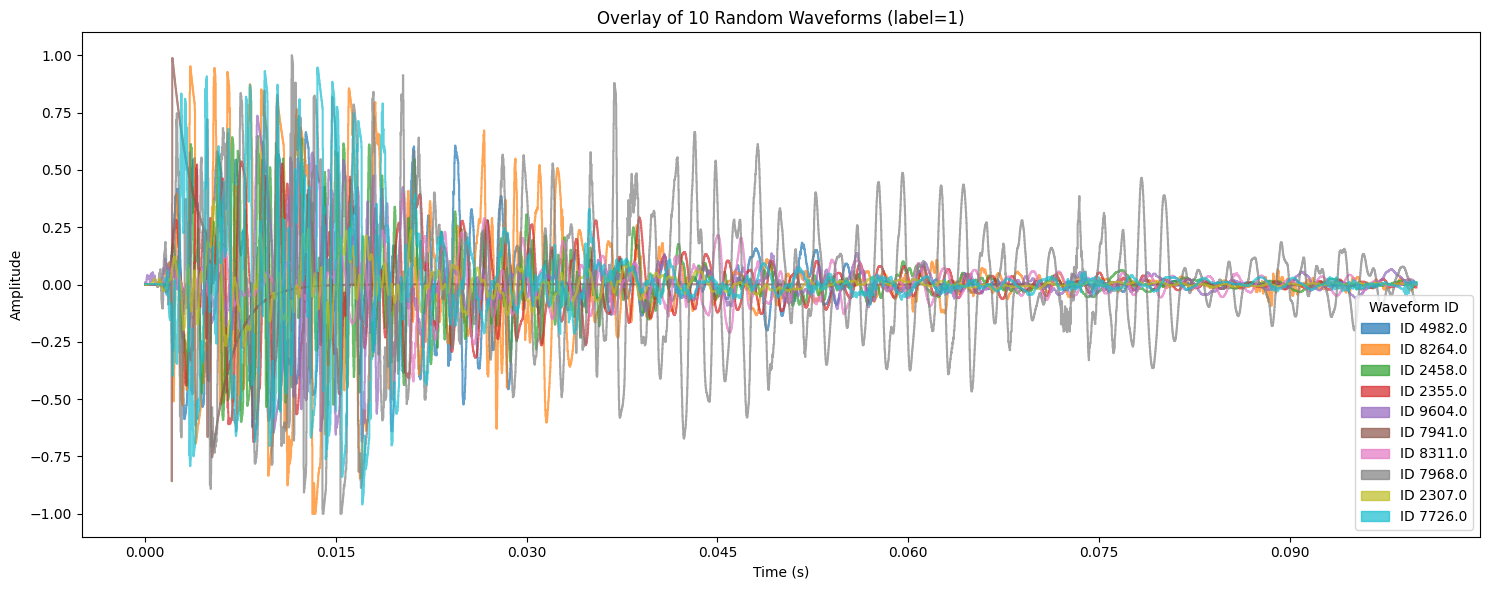

In [72]:
import matplotlib.cm as cm
import numpy as np
import librosa.display

P2_sr = 48000
samples = P2_df[P2_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()
samples = P2_df[P2_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

### PCA Analysis to compare with previous research paper

**Comparing performance on different combinations of extracted features and type of classification model used we need to create more pca objects**

In [73]:
# === PCA EV sweep with fixed nb_hidden {128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import torch
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [128, 64, 32]        #fixed hidden sizes
batch_size = 90
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

results = []

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    #PCA features via your Extract_Features
    P2_PCA = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P2_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds,  test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P2_PCA.get_samples()
    y = P2_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    #SVM baseline (no hidden layers)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))
    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc,
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    #MLP variants over fixed hidden sizes
    for h in hidden_grid:
        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP",         "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P2.pth")

            # Train 
            loops.train(
                model=model,
                model_path=model_path,
                train_loader=train_loader,
                val=False,
                val_loader=None,
                batch_size=batch_size,
                lr=1e-3,
                weight_decay=0,
                optim="adam",
                epochs=epochs,
            )

            # Test and get accuracy directly
            acc = loops.test(
                model=model,
                model_path=model_path,
                test_loader=test_loader,
                report=False,   # set True to see confusion matrix / report
                score=True,
                device=device_str
            )

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })

df_res = pd.DataFrame(results).sort_values(["explained_variance", "model", "nb_hidden"]).reset_index(drop=True)

#color = model, line-dash = nb_hidden (so you can see how hidden width impacts each model)
fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes:128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.4f"}
)
fig.update_layout(hovermode="x unified", yaxis_tickformat=".2%", xaxis=dict(dtick=5))
fig.show()

display(df_res)

[INFO] EPOCH: 1/20
Train loss: 0.767419, Train accuracy: 0.5964
[INFO] EPOCH: 2/20
Train loss: 0.642835, Train accuracy: 0.6802
[INFO] EPOCH: 3/20
Train loss: 0.618082, Train accuracy: 0.7022
[INFO] EPOCH: 4/20
Train loss: 0.578876, Train accuracy: 0.7319
[INFO] EPOCH: 5/20
Train loss: 0.568869, Train accuracy: 0.7382
[INFO] EPOCH: 6/20
Train loss: 0.555528, Train accuracy: 0.7605
[INFO] EPOCH: 7/20
Train loss: 0.545308, Train accuracy: 0.7755
[INFO] EPOCH: 8/20
Train loss: 0.540854, Train accuracy: 0.7759
[INFO] EPOCH: 9/20
Train loss: 0.521796, Train accuracy: 0.7876
[INFO] EPOCH: 10/20
Train loss: 0.507886, Train accuracy: 0.8012
[INFO] EPOCH: 11/20
Train loss: 0.517677, Train accuracy: 0.7916
[INFO] EPOCH: 12/20
Train loss: 0.501295, Train accuracy: 0.8101
[INFO] EPOCH: 13/20
Train loss: 0.492962, Train accuracy: 0.8122
[INFO] EPOCH: 14/20
Train loss: 0.496951, Train accuracy: 0.8162
[INFO] EPOCH: 15/20
Train loss: 0.487138, Train accuracy: 0.8152
[INFO] EPOCH: 16/20
Train loss: 0.

,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,0.763033,99,H=[128]
1,80,MLP (1-layer),32,0.743483,99,H=[32]
2,80,MLP (1-layer),64,0.747630,99,H=[64]
3,80,MLP (2-layer),128,0.750000,99,"H=[128, 64]"
4,80,MLP (2-layer),32,0.752370,99,"H=[32, 16]"
...,...,...,...,...,...,...
75,99,MLP (2-layer),64,0.775474,565,"H=[64, 32]"
76,99,MLP (3-layer),128,0.792062,565,"H=[128, 64, 32]"
77,99,MLP (3-layer),32,0.768365,565,"H=[32, 16, 8]"
78,99,MLP (3-layer),64,0.765995,565,"H=[64, 32, 16]"


### Best Combination

[RETRAIN] EV=96%, model=MLP (1-layer), nb_hidden=128
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp1_ev96_h128_P2_RETRAIN.pth
[INFO] EPOCH: 1/20
Train loss: 0.680238, Train accuracy: 0.6474
[INFO] EPOCH: 2/20
Train loss: 0.564625, Train accuracy: 0.7494
[INFO] EPOCH: 3/20
Train loss: 0.504160, Train accuracy: 0.7955
[INFO] EPOCH: 4/20
Train loss: 0.469787, Train accuracy: 0.8276
[INFO] EPOCH: 5/20
Train loss: 0.440636, Train accuracy: 0.8500
[INFO] EPOCH: 6/20
Train loss: 0.435182, Train accuracy: 0.8599
[INFO] EPOCH: 7/20
Train loss: 0.415671, Train accuracy: 0.8754
[INFO] EPOCH: 8/20
Train loss: 0.397861, Train accuracy: 0.8911
[INFO] EPOCH: 9/20
Train loss: 0.394211, Train accuracy: 0.8914
[INFO] EPOCH: 10/20
Train loss: 0.381087, Train accuracy: 0.9077
[INFO] EPOCH: 11/20
Train loss: 0.382090, Train accuracy: 0.9114
[INFO] EPOCH: 12/20
Train loss: 0.374047, Train accuracy: 0.9107
[INFO] EPOCH: 13/20
Train loss: 0.365308, Train accuracy: 0.9166
[INFO] EPOCH: 14/20
Train l

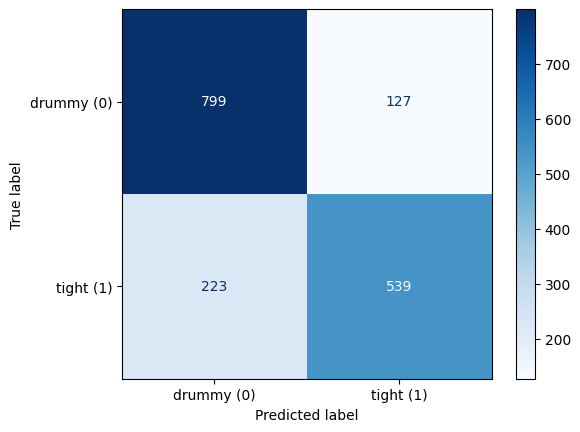


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.78      0.86      0.82       926
   tight (1)       0.81      0.71      0.75       762

    accuracy                           0.79      1688
   macro avg       0.80      0.79      0.79      1688
weighted avg       0.79      0.79      0.79      1688

[RETRAIN] Accuracy (report=True): 0.7927
[GRAPH] Saved to: ../assets/final_report_assets/best_model_mlp1_ev96_h128_P2_RETRAIN.png (and/or .pdf)


In [74]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)

import os, shutil
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 96
BEST_MODEL_NAME = "MLP (1-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 128               # 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag       = ctor_to_tag[ctor_name]

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)
# fresh path so we don't rely on old checkpoints
model_path = os.path.join(model_dir, f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P2_PCA_best = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=best_ev)

# Split (same seed/stratify as before)
y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

# Torch loaders
full_ds   = P2_PCA_best
train_ds  = Subset(full_ds, train_idx.tolist())
test_ds   = Subset(full_ds,  test_idx.tolist())
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P2_PCA_best.get_samples()
input_dim   = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20  # adjust if you want
loops.train(
    model=model,
    model_path=model_path,
    train_loader=train_loader,
    val=False,
    val_loader=None,
    batch_size=batch_size,
    lr=1e-3,
    weight_decay=0,
    optim="adam",
    epochs=epochs,
)

# ----------------- TEST (with report) -----------------
acc = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,   # show confusion matrix + classification report
    score=True,
    device=device_str
)
print(f"[RETRAIN] Accuracy (report=True): {acc:.4f}")

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/final_report_assets/best_model_{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename=graph_fname,
)
print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")